In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from scipy.spatial.distance import pdist

In [10]:
N = 10000
X,t = make_swiss_roll(n_samples=N, noise=0.0)

X=X[:,[0,2]]

X = (X-X.mean())/X.std()

X=torch.tensor(X, dtype=torch.float32)

X_np = X.cpu().numpy()

In [12]:
sigma_single = 0.05

sigma_max = pdist(X_np).max()
sigma_min = 0.01

L = 10

sigma_list = torch.exp(torch.linspace(np.log(sigma_max), np.log(sigma_min), L))
sigma_list = sigma_list.tolist()

def get_sigma(t):

    return sigma_min * (sigma_max/sigma_min)**t

In [15]:
def train_model_single_sigma(
  optimizer_name="Adam",
  lr = 5e-4,
  batch_size = 100,
  width = 128,
  depth = 2,
  sigma = 0.2,
  num_epochs = 5000      
):
    dataset = TensorDataset(X)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    layers = []

    layers.append(nn.Linear(2,width))
    layers.append(nn.ReLU())

    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())


    layers.append(nn.Linear(width,2))

    single_sigma_model = nn.Sequential(*layers)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            single_sigma_model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            single_sigma_model.parameters(),
            lr=lr
        )
    
    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for batch in loader:

            x = batch[0]
            
            eps = torch.randn_like(x)
            
            x_noisy = x + sigma*eps
            
            score_pred = single_sigma_model(x_noisy)

            target = -eps/sigma

            loss = ((score_pred-target)**2).mean()

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

    return single_sigma_model, loss_history    


In [16]:
def train_model_discrete_sigma(
  optimizer_name="Adam",
  lr = 5e-4,
  batch_size = 100,
  width = 128,
  depth = 2,
  num_epochs = 10000      
):
    dataset = TensorDataset(X)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    layers = []

    layers.append(nn.Linear(3,width))
    layers.append(nn.ReLU())

    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())


    layers.append(nn.Linear(width,2))

    discrete_sigma_model = nn.Sequential(*layers)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            discrete_sigma_model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            discrete_sigma_model.parameters(),
            lr=lr
        )
    

    sigma_tensor = torch.tensor(sigma_list, dtype=torch.float32)

    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for (x_batch,) in loader:
            

            idx = torch.randint(0, len(sigma_list), (x_batch.shape[0],))

            sigma_batch = sigma_tensor[idx].unsqueeze(1)
            
            noise = torch.randn_like(x_batch)
            
            x_noisy = x_batch + sigma_batch * noise
            
            target_batch = -noise / sigma_batch

            model_input = torch.cat([x_noisy, sigma_batch], dim=1)

            score_pred = discrete_sigma_model(model_input)

            loss_per_sample = ((score_pred - target_batch) ** 2).sum(dim=1)

            weights = sigma_batch.squeeze() ** 2

            loss = (weights * loss_per_sample).mean()

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

    return discrete_sigma_model, loss_history

In [17]:
def train_model_continuous_sigma(
  optimizer_name="Adam",
  lr = 5e-4,
  batch_size = 100,
  width = 128,
  depth = 2,
  num_epochs = 10000      
):
    dataset = TensorDataset(X)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    layers = []

    layers.append(nn.Linear(3,width))
    layers.append(nn.ReLU())

    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())


    layers.append(nn.Linear(width,2))

    continuous_sigma_model = nn.Sequential(*layers)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            continuous_sigma_model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            continuous_sigma_model.parameters(),
            lr=lr
        )
    

    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for (x_batch,) in loader:
            
            batch_size_current = x_batch.shape[0]
            
            t = torch.rand(batch_size_current,1)

            sigma = get_sigma(t)

            noise = torch.randn_like(x_batch)
            
            x_noisy = x_batch + sigma * noise
            
            target = -noise / sigma

            model_input = torch.cat([x_noisy, sigma], dim=1)

            score_pred = continuous_sigma_model(model_input)

            loss_per_sample = ((score_pred - target) ** 2).sum(dim=1)

            weights = sigma.squeeze() ** 2

            loss = (weights * loss_per_sample).mean()

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

    return continuous_sigma_model, loss_history


In [20]:
def single_sigma_sampling(model, n_samples=5000, eta=0.001, n_steps=500):
    model.eval()
    with torch.no_grad():
    
        x = torch.randn(n_samples, 2)

        for _ in range(n_steps):

            score = model(x)
            noise = torch.randn_like(x)

            x = x + eta*score + np.sqrt(2*eta)*noise

    return x.detach().cpu().numpy()

In [21]:
def discrete_sigma_sampling(model, n_samples=10000, eta=1e-5, num_steps_each_sigma=1000):
    
    model.eval()

    with torch.no_grad():

        x = torch.randn(n_samples, 2)
        
        for sigma in sigma_list:
            sigma_tensor = torch.full((x.shape[0], 1), sigma) 
     
            for _ in range(num_steps_each_sigma):

                model_input = torch.cat([x, sigma_tensor], dim=1)

                score = model(model_input)

                noise = torch.randn_like(x)

                x = x + eta * score + np.sqrt(2 * eta) * noise

    return x.detach().cpu().numpy()

In [ ]:
def g(t):

    sigma = get_sigma(t)

    return (sigma * np.sqrt(2*np.log(sigma_max/sigma_min)))


def continuous_sigma_sampling(model, n_samples=10000, n_steps=1000):
    model.eval()

    dt = 1.0/n_steps

    x = torch.randn(n_samples, 2)*sigma_max

    with torch.no_grad():

        for i in range(n_steps):

            t = 1 - i/n_steps

            t_tensor = torch.full((n_samples,1), t)

            sigma = get_sigma(t_tensor)

            g_val = g(t_tensor)

            model_input = torch.cat([x, sigma], dim=1)

            score = model(model_input)

            noise = torch.randn_like(x)
            
            x = (x+(g_val**2)*score*dt+g_val*torch.sqrt(torch.tensor(dt))*noise)

    return x.detach().cpu().numpy()


In [24]:
model_single_sigma, loss_history_single_sigma = train_model_single_sigma(sigma=0.05, num_epochs=5000)

In [25]:
model_discrete_sigma, loss_history_discrete_sigma = train_model_discrete_sigma(num_epochs=10000)

In [26]:
model_continuous_sigma, loss_history_continuous_sigma = train_model_continuous_sigma(num_epochs=10000)

In [27]:
x_single_sigma = single_sigma_sampling(model_single_sigma, n_samples=10000, eta=0.001, n_steps=500)
x_discrete_sigma = discrete_sigma_sampling(model_discrete_sigma, n_samples=10000, eta=1e-5, num_steps_each_sigma=1000)
x_continuous_sigma = continuous_sigma_sampling(model_continuous_sigma, n_samples=10000, n_steps=1000)

Text(0.5, 1.0, 'Continuous Sigma Sampling')

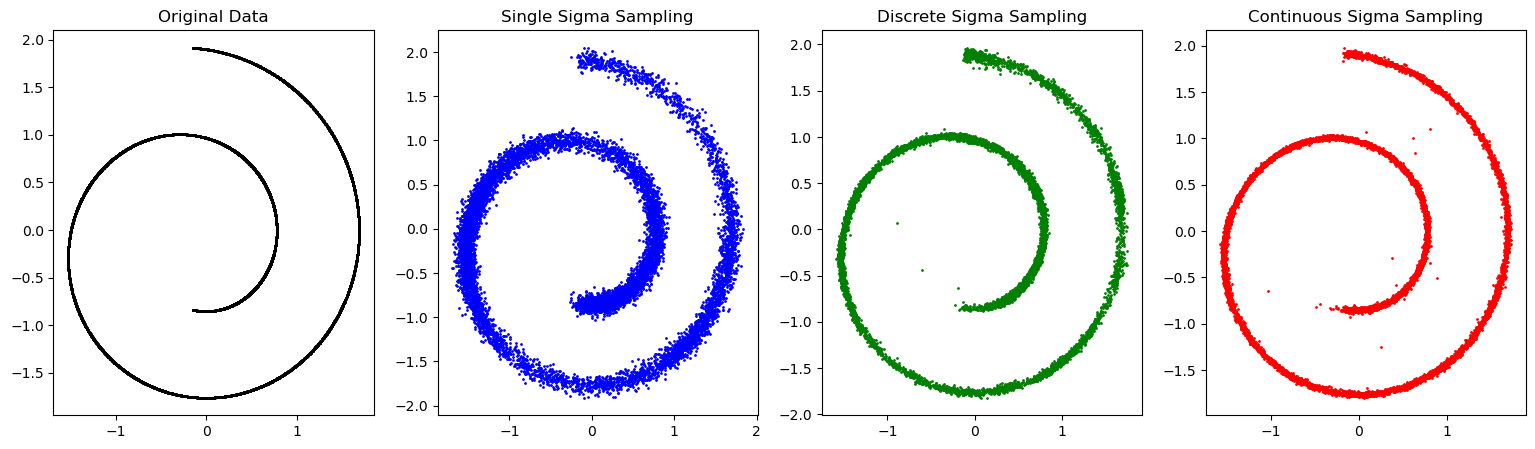

In [34]:
fig, axs = plt.subplots(1, 4, figsize=(19, 5))
axs[0].scatter(X_np[:, 0], X_np[:, 1], c='black', s=1)
axs[0].set_title('Original Data')
axs[1].scatter(x_single_sigma[:, 0], x_single_sigma[:, 1], c='blue', s=1)
axs[1].set_title('Single Sigma Sampling')
axs[2].scatter(x_discrete_sigma[:, 0], x_discrete_sigma[:, 1], c='green', s=1)
axs[2].set_title('Discrete Sigma Sampling')
axs[3].scatter(x_continuous_sigma[:, 0], x_continuous_sigma[:, 1], c='red', s=1)
axs[3].set_title('Continuous Sigma Sampling')

In [38]:
bins = 100
H_real, xedges, yedges = np.histogram2d(
    X[:,0], X[:,1],
    bins=bins,
    density=True
)

H_single_sigma, _, _ = np.histogram2d(
    x_single_sigma[:,0],
    x_single_sigma[:,1],
    bins=[xedges, yedges],
    density=True
)

difference_single_sigma = np.sum(np.abs(H_real - H_single_sigma))
print(difference_single_sigma)

H_discrete_sigma, _, _ = np.histogram2d(
    x_discrete_sigma[:,0],x_discrete_sigma[:,1],
    bins=[xedges, yedges],
    density=True
)
difference_discrete_sigma = np.sum(np.abs(H_real - H_discrete_sigma))
print(difference_discrete_sigma)

H_continuous_sigma, _, _ = np.histogram2d(
    x_continuous_sigma[:,0],x_continuous_sigma[:,1],
    bins=[xedges, yedges],
    density=True
)
difference_continuous_sigma = np.sum(np.abs(H_real - H_continuous_sigma))
print(difference_continuous_sigma)

1192.561326965994
777.7903339446215
477.7972654528833


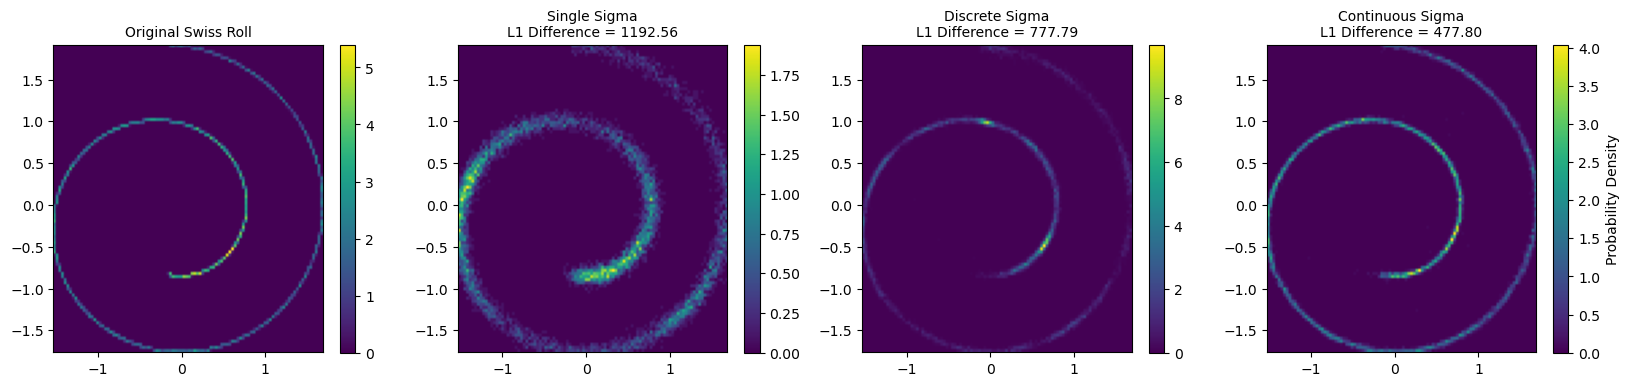

In [51]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))

im1= ax[0].imshow(
    H_real.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[0].set_title("Original Swiss Roll", fontsize=10)

im2=ax[1].imshow(
    H_single_sigma.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[1].set_title(f"Single Sigma\nL1 Difference = {difference_single_sigma:.2f}", fontsize=10)

im3=ax[2].imshow(
    H_discrete_sigma.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[2].set_title(f"Discrete Sigma\nL1 Difference = {difference_discrete_sigma:.2f}", fontsize=10)

im4=ax[3].imshow(
    H_continuous_sigma.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[3].set_title(f"Continuous Sigma\nL1 Difference = {difference_continuous_sigma:.2f}", fontsize=10)

colorbar1 = fig.colorbar(im1, ax=ax[0])
colorbar2 = fig.colorbar(im2, ax=ax[1])
colorbar3 = fig.colorbar(im3, ax=ax[2])
colorbar4 = fig.colorbar(im4, ax=ax[3], label="Probability Density")

plt.show()